# Global Housing Market Dynamics: An Analysis (2015-2024)
*(Note: Title should be different from the original dataset title as per guidelines)*

**Student Name:** Risav Ganguly
**Student ID:** 004003540

**Objective:** Analyze global housing market trends from 2015 to 2024, focusing on price indices, affordability, and their correlation with economic indicators like GDP growth and inflation.

**Dataset:** Global Housing Market Analysis (2015-2024) from Kaggle.
[Link: https://www.kaggle.com/datasets/atharvasoundankar/global-housing-market-analysis-2015-2024]

This notebook explores the dataset, cleans it, performs exploratory analysis, visualizes key trends, and derives insights into housing affordability and market drivers across selected countries.

## 1. Importing Libraries
Import necessary Python libraries for data analysis and visualization.

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

## 2. Data Loading

In [157]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('global_housing_market_extended.csv')

## 3. Data Understanding and Cleaning

**Objective:** Understand the dataset structure, content, and quality, and perform necessary cleaning steps.

### 3.1 Initial Data Examination
Examine the first few rows, data types, column names, and check for missing values.

In [160]:
# Examining the first few rows
print("--- First 5 Rows ---")
print(df.head())

# Examining datatypes and structure (non-null counts)
print("\n--- DataFrame Info ---")
df.info()

# Listing columns of interest (all columns in this case)
print("\n--- Column Names ---")
print(df.columns)

# Checking for null values
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

--- First 5 Rows ---
  Country  Year  House Price Index  Rent Index  Affordability Ratio  \
0     USA  2015         117.454012  116.550001             9.587945   
1     USA  2016         150.807258   51.440915            11.729189   
2     USA  2017         123.194502   70.386040             8.506676   
3     USA  2018         131.423444   91.469020             3.418054   
4     USA  2019         110.461377   56.837048             9.158097   

   Mortgage Rate (%)  Inflation Rate (%)  GDP Growth (%)  \
0           4.493292            1.514121       -0.752044   
1           5.662213            1.880204       -0.545400   
2           2.197469            2.398940        0.930895   
3           4.537724            1.608407       -1.479587   
4           3.700762            1.293249        1.961415   

   Population Growth (%)  Urbanization Rate (%)  Construction Index  
0              -0.796707              85.985284          118.089201  
1              -0.358084              69.127267    

### 3.2 Data Cleaning Requirements

Addressing specific cleaning needs outlined in the guidelines.

**Handling Missing Values:**
* As determined above, there are no missing values, so no imputation or removal is needed.

**Rename Columns:**
* Standardize column names containing special characters (%) for easier access.

In [163]:
# Rename columns for easier referencing
df.rename(columns={
    'Mortgage Rate (%)': 'Mortgage_Rate_Perc',
    'Inflation Rate (%)': 'Inflation_Rate_Perc',
    'GDP Growth (%)': 'GDP_Growth_Perc',
    'Population Growth (%)': 'Population_Growth_Perc',
    'Urbanization Rate (%)': 'Urbanization_Rate_Perc'
}, inplace=True)

print("--- Columns Renamed ---")
print(df.columns)

--- Columns Renamed ---
Index(['Country', 'Year', 'House Price Index', 'Rent Index',
       'Affordability Ratio', 'Mortgage_Rate_Perc', 'Inflation_Rate_Perc',
       'GDP_Growth_Perc', 'Population_Growth_Perc', 'Urbanization_Rate_Perc',
       'Construction Index'],
      dtype='object')


**Check for Duplicates:**
* Verify if there are any duplicate rows in the dataset.

In [166]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\n--- Duplicate Rows Check ---")
print(f"Number of duplicate rows: {duplicate_rows}")


--- Duplicate Rows Check ---
Number of duplicate rows: 0


**Convert Data Types (If Needed):**
* The 'Year' column is currently `int64`. While it can be treated as numeric for line plots, converting it to 'category' or 'object' might be useful for certain types of grouping or analysis, though not strictly necessary for the planned visualizations. We will keep it as int64 for now.

**Ensure Numeric Columns are Valid:**
* Check basic statistics to ensure numeric columns like rates are within expected ranges (e.g., non-negative mortgage rates).

In [169]:
# Displaying summary statistics to check validity (e.g., min/max values)
print("\n--- Summary Statistics (Post-Cleaning) ---")
print(df.describe())
# Finding: Minimum values for percentage columns appear reasonable (no negative mortgage rates observed).


--- Summary Statistics (Post-Cleaning) ---
              Year  House Price Index  Rent Index  Affordability Ratio  \
count   200.000000         200.000000  200.000000           200.000000   
mean   2019.500000         130.381022   83.048370             7.237768   
std       2.879489          28.752229   21.439858             2.576085   
min    2015.000000          80.552212   50.354311             3.041688   
25%    2017.000000         104.142562   60.466671             5.034207   
50%    2019.500000         129.193653   83.721711             7.375697   
75%    2022.000000         157.127098  100.604665             9.276196   
max    2024.000000         179.971767  119.855388            11.879671   

       Mortgage_Rate_Perc  Inflation_Rate_Perc  GDP_Growth_Perc  \
count          200.000000           200.000000       200.000000   
mean             4.150621             3.649756         2.133722   
std              1.380222             1.881938         2.413270   
min              1.53

### 3.3 Documentation of Cleaning
* **Missing Values:** No missing values were present.
* **Column Renaming:** Columns with '%' were renamed to use '_Perc' for easier coding. This was done for standardization.
* **Duplicates:** No duplicate rows were found.
* **Type Conversion:** 'Year' kept as integer type. No other type conversions deemed necessary.
* **Validity:** Basic statistics confirm reasonable ranges for numeric data.

## 4. Exploratory Data Analysis (EDA)

Perform initial analysis to understand structure, statistics, and identify potential anomalies.

In [173]:

# Summary statistics already examined in df.describe()

# Count of countries and year range
print("--- Dataset Overview ---")
num_countries = df['Country'].nunique()
min_year, max_year = df['Year'].min(), df['Year'].max()
print(f"Number of unique countries: {num_countries}") 
print(f"Year range: {min_year} - {max_year}") 

# Summary of key indicators (Affordability and Housing)
print("\n--- Summary of Key Indicators ---")
print(df[['House Price Index', 'Rent Index', 'Affordability Ratio', 'Mortgage_Rate_Perc']].describe())

--- Dataset Overview ---
Number of unique countries: 20
Year range: 2015 - 2024

--- Summary of Key Indicators ---
       House Price Index  Rent Index  Affordability Ratio  Mortgage_Rate_Perc
count         200.000000  200.000000           200.000000          200.000000
mean          130.381022   83.048370             7.237768            4.150621
std            28.752229   21.439858             2.576085            1.380222
min            80.552212   50.354311             3.041688            1.537814
25%           104.142562   60.466671             5.034207            3.045278
50%           129.193653   83.721711             7.375697            4.329643
75%           157.127098  100.604665             9.276196            5.217706
max           179.971767  119.855388            11.879671            6.485623


## 5. Data Visualization and Interpretation

Visualizing trends and relationships in the data. Each plot includes a title, labels, and interpretation.

### 5.1.1 Correlation Analysis (Heatmap)
Using a heatmap to understand correlations between numerical variables.

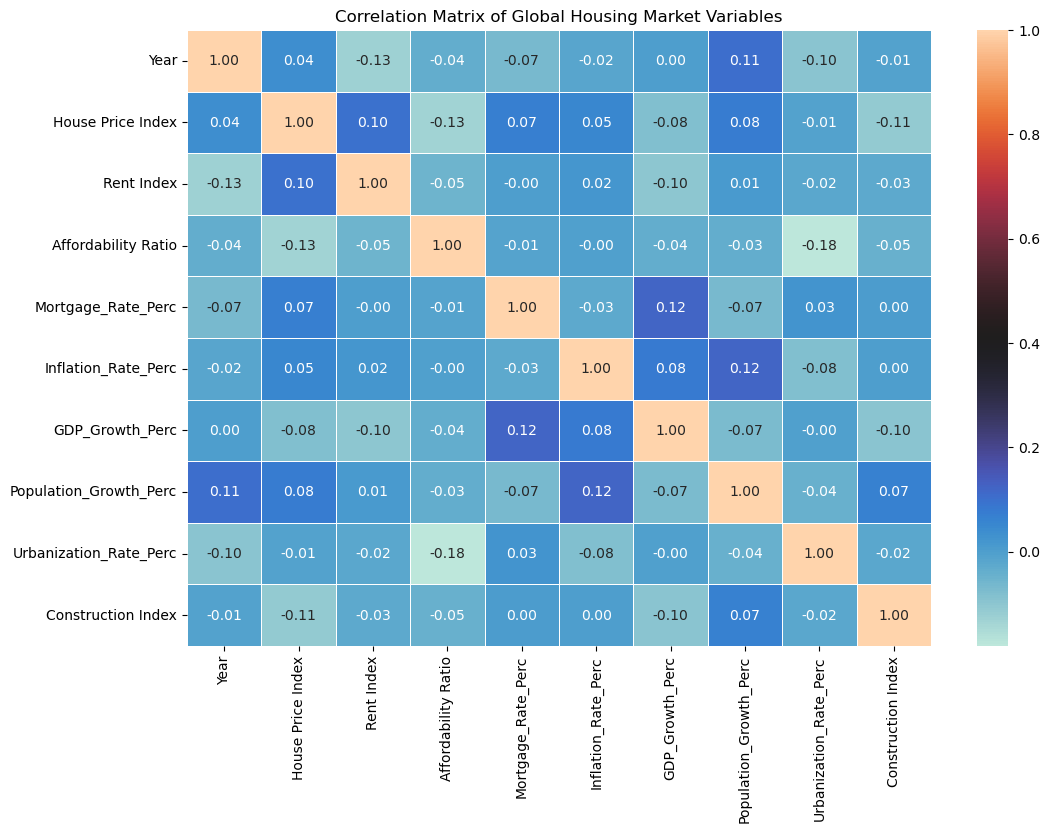

In [282]:
# Calculate the correlation matrix (numeric columns only)
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 8)) # Adjusted size slightly
sns.heatmap(correlation_matrix, cmap='icefire', annot=True, fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Global Housing Market Variables')
plt.savefig("5.1.1.png")
plt.show()

**Interpretation:** 
* Inflation shows a weak positive correlation with Population Growth. Mortgage Rate shows a weak positive correlation with GDP Growth.
* Nothing shows a strong correlation 

### 5.1.2 House Price Index Trends (Faceted Line Plot)
Tracking the House Price Index over time for each country individually.`

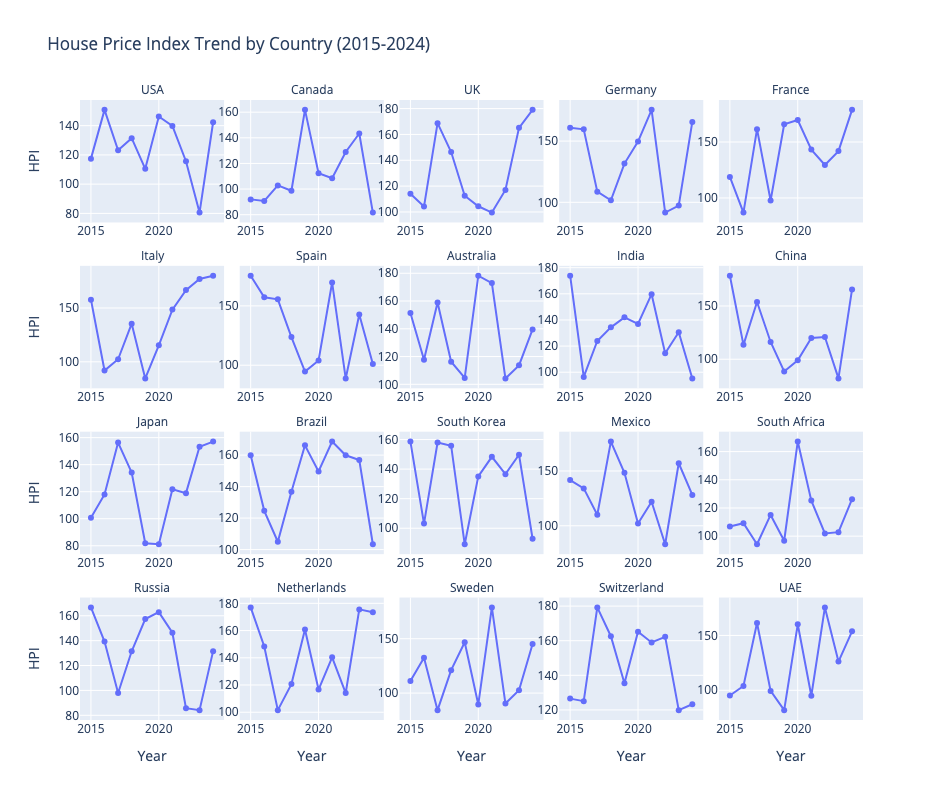

In [286]:
fig_hpi_facet = px.line(df,
                        x='Year',
                        y='House Price Index',
                        facet_col='Country', # Subplot per country
                        facet_col_wrap=5,   # Wrap after 5 columns
                        title = 'House Price Index Trend by Country (2015-2024)',
                        height=800,
                        markers=True,
                        labels={'House Price Index': 'HPI', 'Year': 'Year'})
fig_hpi_facet.update_yaxes(matches=None, showticklabels=True)
fig_hpi_facet.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig_hpi_facet.update_xaxes(showticklabels=True)
fig_hpi_facet.update_layout(showlegend=False)
fig_hpi_facet.write_html("5.1.2.html")
fig_hpi_facet.show() 

### 5.2 Average House Price Index by Country (Bar Plot)
Comparing the average House Price Index (HPI) across the different countries over the 2015-2024 period to identify regions with generally higher or lower housing price levels relative to the base year.

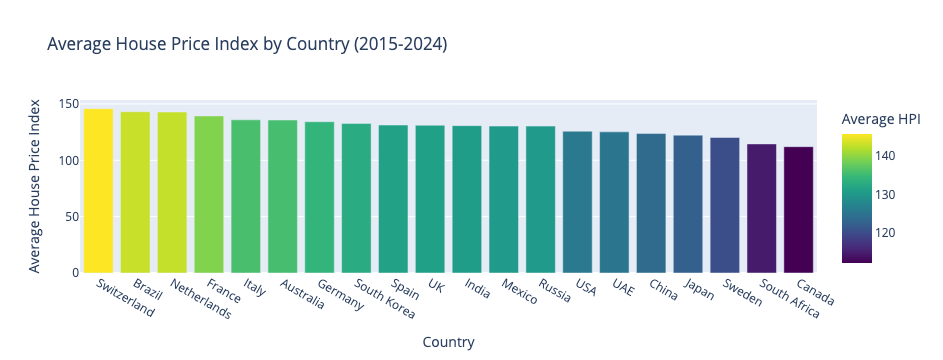

In [288]:
# Calculating average HPI per country
avg_hpi_country = df.groupby('Country')['House Price Index'].mean().reset_index().sort_values('House Price Index', ascending=False)

fig_avg_hpi = px.bar(avg_hpi_country,
                     x='Country',
                     y='House Price Index',
                     title='Average House Price Index by Country (2015-2024)', 
                     labels={'House Price Index': 'Average HPI'}, 
                     color='House Price Index', # Color by HPI value
                     color_continuous_scale=px.colors.sequential.Viridis) # Color scale

fig_avg_hpi.update_layout(xaxis_title="Country", yaxis_title="Average House Price Index") 
fig_avg_hpi.write_html("5.2.html")
fig_avg_hpi.show() # Displaying the plot

**Interpretation:**
* This bar chart compares the average House Price Index across the surveyed countries for the entire period (2015-2024).
* *Observation:* Countries like Switzerland, France, Italy, UK, and Netherlands show higher average HPI values over this period, suggesting generally higher housing prices relative to their baseline compared to others.
* *Observation:* Countries like Canada, India, Japan, and South Korea appear to have lower average HPI values during this timeframe.
* *Note:* This shows the average level, not the trend (which was seen in the faceted plot). A high average could mean consistently high prices or a significant recent increase.

### 5.3 Mortgage Rate Distribution (Histogram)
Understanding the distribution and spread of average mortgage rates across the dataset (all countries, all years combined).

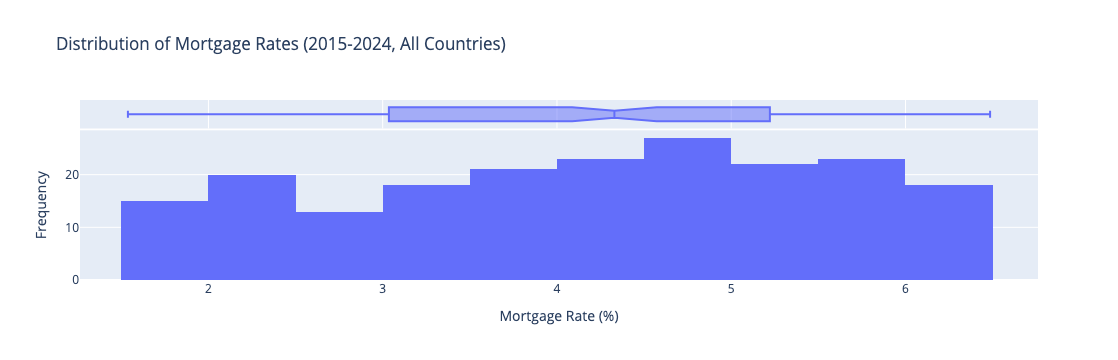

In [237]:
# Creating the histogram using Plotly Express
fig_mortgage_hist = px.histogram(df,
                                 x='Mortgage_Rate_Perc',
                                 title='Distribution of Mortgage Rates (2015-2024, All Countries)', 
                                 labels={'Mortgage_Rate_Perc': 'Mortgage Rate (%)'}, 
                                 nbins=15, # Adjusting number of bins as needed
                                 marginal="box" # Adding a box plot to show quartiles/outliers
                                )

fig_mortgage_hist.update_layout(xaxis_title="Mortgage Rate (%)", yaxis_title="Frequency")
fig_mortgage_hist.write_html("5.3.html")
fig_mortgage_hist.show() # Displaying the plot

**Interpretation:** 
* This histogram shows the frequency distribution of mortgage rates recorded across all countries and years in the dataset.
* *Observation:* The distribution appears somewhat multimodal, with peaks suggesting common rate clusters. The bulk of the rates seem to rise between roughly 3% and 5.5%.
* *Observation:* The box plot indicates the median mortgage rate is around 4.0-4.5%, with the interquartile range spanning roughly 3.0% to 5.0%. There are some values extending towards 6.5%.

### 5.4 House Price Index vs. Rent Index (Scatter Plot)
Exploring the relationship between the House Price Index and the Rent Index to gauge relative housing cost dynamics (using data for 2024 for a snapshot).

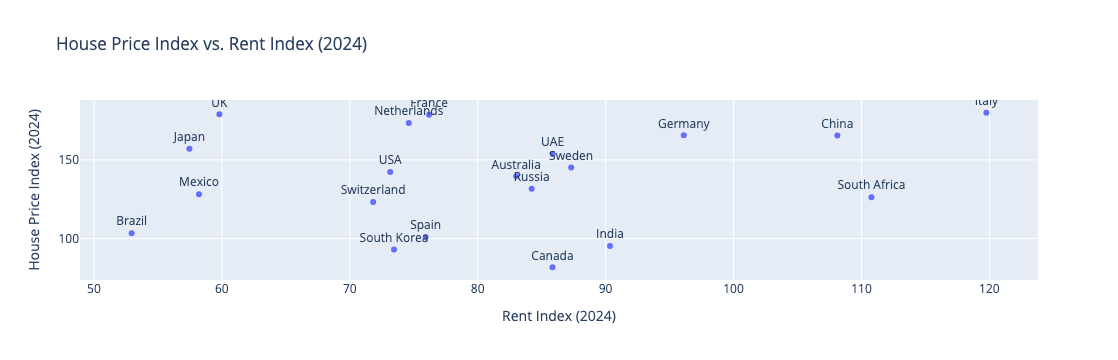

In [239]:
# Filtering data for the year 2024
df_2024_scatter = df[df['Year'] == 2024].copy()

# Creating the scatter plot
fig_hpi_rent = px.scatter(df_2024_scatter,
                          x='Rent Index',
                          y='House Price Index',
                          title='House Price Index vs. Rent Index (2024)',
                          labels={'Rent Index': 'Rent Index', 'House Price Index': 'House Price Index'}, 
                          text='Country', # Label points with country names
                          hover_data=['Country']) # Showing country on hover

fig_hpi_rent.update_traces(textposition='top center') # Adjusting" text label position
fig_hpi_rent.update_layout(xaxis_title="Rent Index (2024)", yaxis_title="House Price Index (2024)") 
fig_hpi_rent.write_html("5.4.html")
fig_hpi_rent.show() # Displaying the plot

**Interpretation:**
* This scatter plot shows the relationship between the Rent Index and House Price Index for different countries in 2024.
* *Observation:* There doesn't appear to be a strong linear correlation between the Rent Index and House Price Index across these countries in 2024. Countries are scattered across the plot.
* *Observation:* For example, Italy and the UK have high HPI but varying Rent Index values in 2024. India and South Korea have relatively low HPI and Rent Index values in this snapshot.
* *Note:* This relationship can be complex. A high HPI with a lower Rent Index might suggest a market more favorable to renters than buyers (or a potential housing bubble), while the opposite might indicate high rental demand relative to purchase prices.

### 5.5 Affordability Ratio Over Time (Line Plot)
Tracking the average affordability ratio globally over the years 2015-2024.

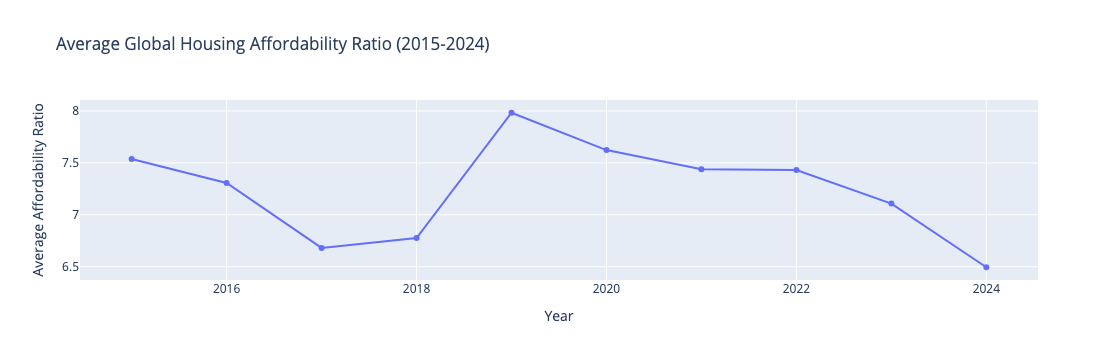

In [243]:
# Calculating average affordability ratio per year
avg_affordability_time = df.groupby('Year')['Affordability Ratio'].mean().reset_index()

# Creating the line plot
fig_afford_time = px.line(avg_affordability_time,
                          x='Year',
                          y='Affordability Ratio',
                          title='Average Global Housing Affordability Ratio (2015-2024)',
                          labels={'Affordability Ratio': 'Average Affordability Ratio (Lower is Better)', 'Year': 'Year'}, 
                          markers=True) # Showing markers for each year

fig_afford_time.update_layout(xaxis_title="Year", yaxis_title="Average Affordability Ratio") 
fig_afford_time.write_html("5.5.html")
fig_afford_time.show() # Displaying the plot

**Interpretation:** 
* This line plot shows the trend of the average Affordability Ratio across all included countries from 2015 to 2024.
* *Observation:* The average global affordability ratio appears relatively stable but shows a slight worsening trend (increase) from 2015 up to 2017, followed by a stark incease from 2018 to 2019. There's a noticeable dip after 2019 too.
* *Observation:* Overall, the average ratio remained within the 6.5 to 8.0 range during this period for the countries in the dataset.
* *Note:* This global average masks significant variations between individual countries, as seen in other plots.

### 5.6 Average House Price Index by Country (Geo Map) `
Visualizing the geographic distribution of the average House Price Index (2015-2024).

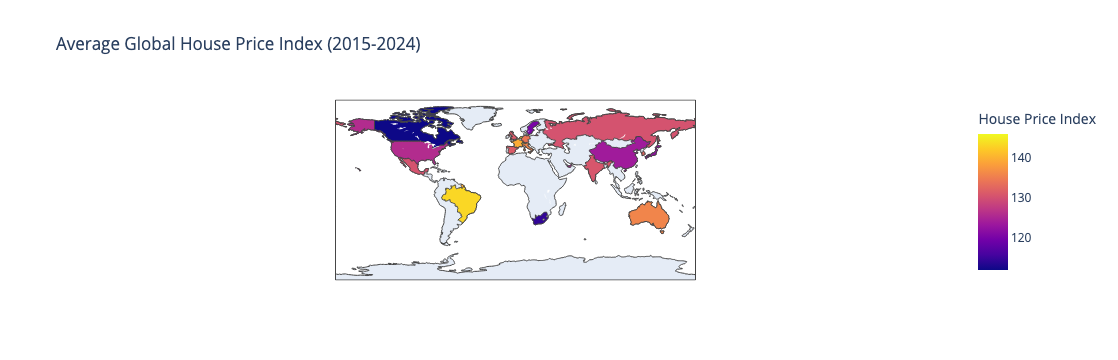

In [245]:
# Reuseing the avg_hpi_country DataFrame calculated earlier
# Creating the choropleth map
fig_map = px.choropleth(avg_hpi_country, # Using the aggregated data
                        locations="Country",               # Column with country names
                        locationmode="country names",    # Specify location type
                        color="House Price Index",       # Variable to map to color
                        hover_name="Country",            # Show country on hover
                        hover_data={'House Price Index':':.2f', 'Country':False}, # Format hover data
                        color_continuous_scale=px.colors.sequential.Plasma, # Color scale
                        title="Average Global House Price Index (2015-2024)",
                       )
fig_map.write_html("5.6.html")
fig_map.show() # Displaying the map

**Interpretation:** 
* The choropleth map displays the average House Price Index for each country over the 2015-2024 period, using color intensity to represent the index level.
* *Observation:* European countries (like Switzerland, France, Germany, Italy, UK, Netherlands) and the UAE tend to show higher average HPI values (darker colors on this scale).
* *Observation:* North American countries (USA, Canada, Mexico), Brazil, South Africa, India, and East Asian countries (South Korea, Japan, China, Australia) generally show lower average HPI values during this period (lighter colors).
* *Note:* This map provides a geographical perspective on the average price levels discussed in the bar chart (Visualization 5.2).

## 6. Additional Analysis/Findings 

This section includes at least 3 additional visualizations/analyses chosen to explore the data further.

### 6.1 Change in House Price Index (2015 vs 2024) - Bar Chart`
*Purpose: To visually compare the magnitude and direction of HPI changes across countries between the start and end years.*

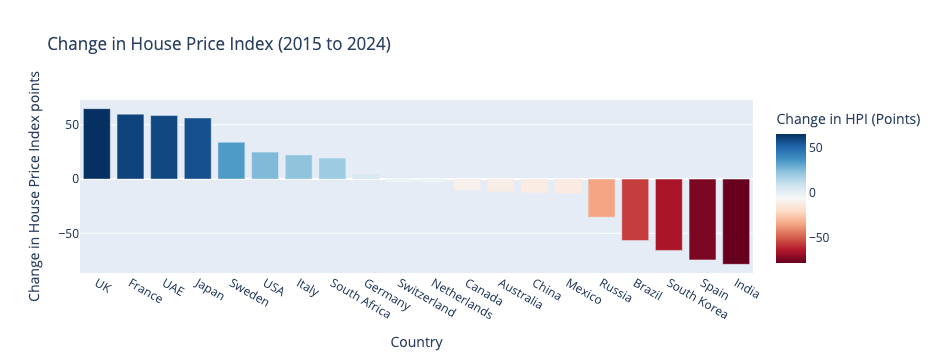

In [271]:
# --- Visualization: Change in HPI (2015-2024) --- # 
# Calculate the change in House Price Index between 2015 and 2024
hpi_start = df[df['Year'] == 2015].set_index('Country')['House Price Index']
hpi_end = df[df['Year'] == 2024].set_index('Country')['House Price Index']
hpi_change = (hpi_end - hpi_start).reset_index()
hpi_change.columns = ['Country', 'HPI Change (2024 - 2015)']

# Sort by change for better visualization
hpi_change = hpi_change.sort_values('HPI Change (2024 - 2015)', ascending=False)

# Create a bar chart of the HPI change
fig_hpi_change = px.bar(hpi_change,
                        x='Country', y='HPI Change (2024 - 2015)', 
                        title='Change in House Price Index (2015 to 2024)', 
                        color='HPI Change (2024 - 2015)',
                        color_continuous_scale=px.colors.diverging.RdBu, # Diverging scale shows +/- changes well
                        labels={'HPI Change (2024 - 2015)': 'Change in HPI (Points)'}) 

fig_hpi_change.update_layout(xaxis_title="Country",
                             yaxis_title="Change in House Price Index points") 
fig_hpi_change.write_html("6.1.html")
fig_hpi_change.show()

**Interpretation:**
* This bar chart explicitly shows the net change in HPI points from 2015 to 2024 for each country.
* *Observation:* The UK, France, UAE, and Japan experienced the largest positive changes (increases) in their HPI over this period.
* *Observation:* Conversely, India, Spain, South Korea, and Brazil saw the largest negative changes (decreases) in their HPI.
* *Observation:* Several countries, including the USA, Germany, Canada, and Australia, had relatively smaller net changes (both positive and negative), suggesting more stability or cyclical movements that resulted in less overall change between these two specific years.

### 6.2 House Price Index vs. Affordability Ratio (2024) - Scatter Plot
*Purpose: To investigate the relationship between current house price levels and affordability in the most recent year.*

Generating Scatter Plot for HPI vs Affordability (2024)...


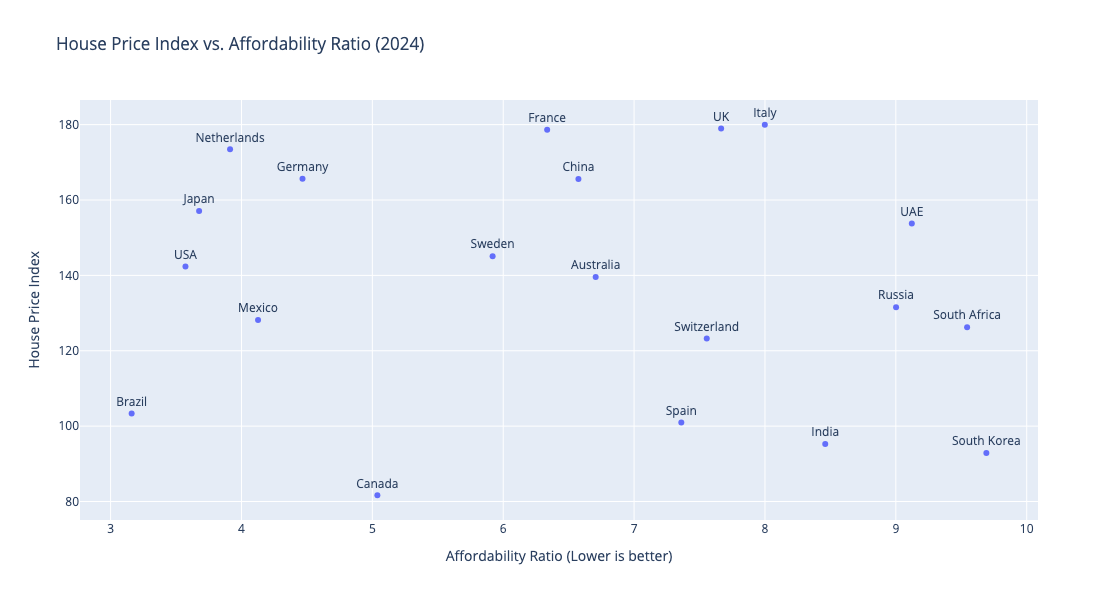

In [249]:
print("Generating Scatter Plot for HPI vs Affordability (2024)...")
df_2024 = df[df['Year'] == 2024]
fig_scatter_2024 = px.scatter(df_2024,
                              x='Affordability Ratio',
                              y='House Price Index',
                              text='Country', # Label points
                              title='House Price Index vs. Affordability Ratio (2024)', 
                              labels={'Affordability Ratio': 'Affordability Ratio (Lower is better)', 
                                      'House Price Index': 'House Price Index'},
                              hover_data=['Country', 'Mortgage_Rate_Perc', 'GDP_Growth_Perc'])

fig_scatter_2024.update_traces(textposition='top center')
fig_scatter_2024.update_layout(height=600, xaxis_title='Affordability Ratio (Lower is better)', yaxis_title='House Price Index') 
fig_scatter_2024.write_html("6.2.html")
fig_scatter_2024.show() # Display the plot

**Interpretation:**
* This plot examines the relationship between HPI and the Affordability Ratio in 2024. Lower affordability ratios indicate better affordability.
* *Observation:* There isn't a clear universal trend. High HPI doesn't always mean poor affordability, and vice-versa.
* *Observation:* For instance, in 2024, Italy and France have very high HPIs but middling affordability ratios. The UK has both a high HPI and a relatively high (worse) affordability ratio.
* *Observation:* South Korea and South Africa show poor affordability ratios despite having lower HPIs compared to the highest countries. Brazil shows good affordability despite a relatively low HPI.
* *Note:* This suggests factors beyond just the price index heavily influence affordability (like income levels, mortgage rates – not directly shown on axes but available in hover data).

### 6.3 Average Affordability Ratio by Country (Bar Plot)
*Purpose: To compare the overall average affordability across countries during the period.*

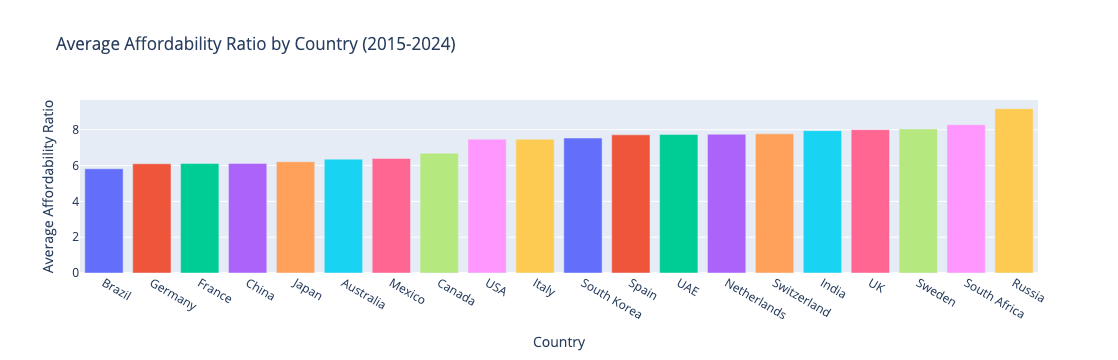

In [251]:
# Calculate average affordability per country
avg_affordability = df.groupby('Country')['Affordability Ratio'].mean().reset_index().sort_values('Affordability Ratio')

# Create the bar plot
fig_affordability = px.bar(avg_affordability,
                           x='Country',
                           y='Affordability Ratio',
                           title='Average Affordability Ratio by Country (2015-2024)',
                           color='Country', # Color bars by country
                           labels={'Affordability Ratio': 'Average Affordability Ratio (Lower is Better)'})

fig_affordability.update_layout(xaxis_title="Country",
                                yaxis_title="Average Affordability Ratio",
                                showlegend=False) # Hiding redundant legend
fig_affordability.write_html("6.3.html")
fig_affordability.show() 

**Interpretation:** 
* This chart ranks countries by their average affordability ratio over the 2015-2024 period. Lower bars indicate better average affordability.
* *Observation:* Brazil, Germany, France, China, and Japan show the best average affordability ratios among these countries.
* *Observation:* Russia, South Africa, Sweden, and the UK show the highest (worst) average affordability ratios over this period.
* *Note:* Comparing this to the average HPI chart (Viz 5.2) highlights differences - e.g., Germany has a high average HPI but good average affordability, while Russia has a mid-range average HPI but the worst average affordability.

### 6.4 Affordability Change vs. Average GDP Growth (Scatter Plot)
*Purpose: To explore if economic growth (represented by average GDP growth) correlates with changes in housing affordability over the period.*

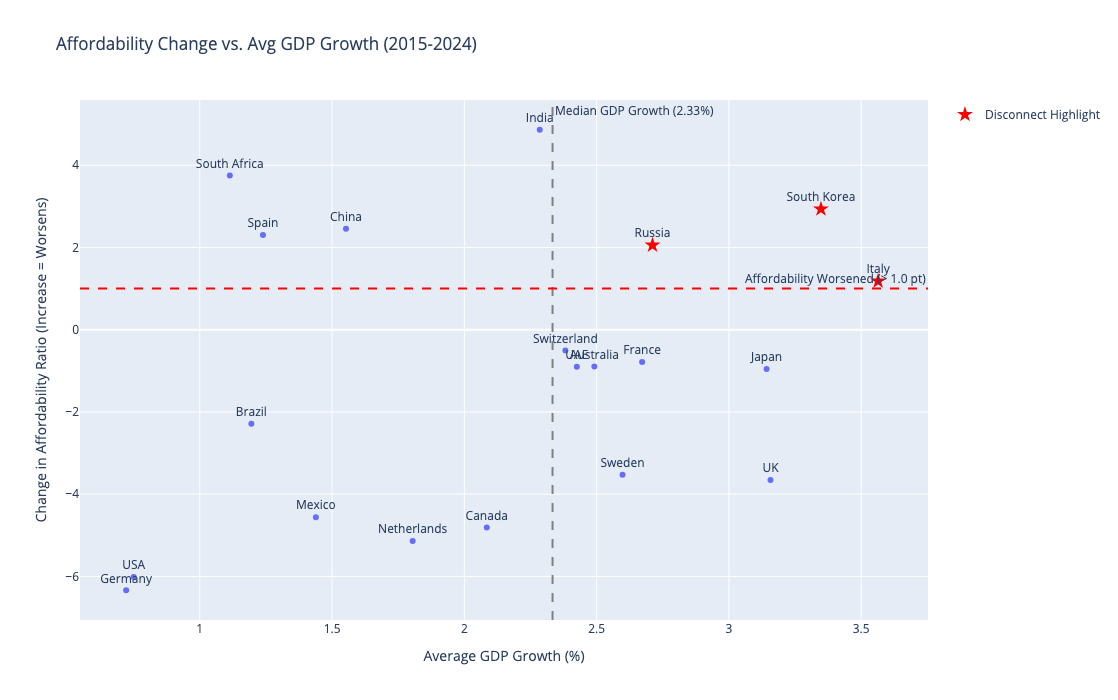

In [253]:
# --- Visualization: Affordability Change vs GDP Growth --- # 
# Calculate Affordability Ratio change
aff_start = df[df['Year'] == 2015].set_index('Country')['Affordability Ratio']
aff_end = df[df['Year'] == 2024].set_index('Country')['Affordability Ratio']
aff_change = (aff_end - aff_start).rename('Affordability Change (15-24)')

# Calculate Average GDP Growth
avg_gdp = df.groupby('Country')['GDP_Growth_Perc'].mean().rename('Avg GDP Growth % (15-24)')
gdp_aff_data = pd.concat([aff_change, avg_gdp], axis=1).reset_index()

# Defining threshold for worsening affordability (e.g., increase > 1 point)
affordability_worsen_threshold = 1.0
disconnect_countries = gdp_aff_data[
    (gdp_aff_data['Affordability Change (15-24)'] > affordability_worsen_threshold) &
    (gdp_aff_data['Avg GDP Growth % (15-24)'] > gdp_aff_data['Avg GDP Growth % (15-24)'].median())
]['Country'].tolist()

# Creating the scatter plot
fig2 = px.scatter(gdp_aff_data,
                  x='Avg GDP Growth % (15-24)', y='Affordability Change (15-24)', text='Country',
                  title='Affordability Change vs. Avg GDP Growth (2015-2024)', 
                  labels={'Avg GDP Growth % (15-24)': 'Average GDP Growth (%)', 
                          'Affordability Change (15-24)': 'Change in Affordability Ratio (Increase = Worsens)'},
                  hover_data=['Country'])

# Adding median GDP line
median_gdp_growth = avg_gdp.median()
fig2.add_vline(x=median_gdp_growth, line_dash="dash", line_color="grey", annotation_text=f"Median GDP Growth ({median_gdp_growth:.2f}%)")

# Adding affordability worsening line
fig2.add_hline(y=affordability_worsen_threshold, line_dash="dash", line_color="red", annotation_text=f"Affordability Worsened (> {affordability_worsen_threshold} pt)")

# Highlighting countries with above-median growth but worsening affordability
highlight_data = gdp_aff_data[gdp_aff_data['Country'].isin(disconnect_countries)]
fig2.add_trace(go.Scatter(x=highlight_data['Avg GDP Growth % (15-24)'], y=highlight_data['Affordability Change (15-24)'],
                           mode='markers',
                           marker=dict(color='red', size=12, symbol='star'),
                           name='Disconnect Highlight', # Legend entry
                           text=highlight_data['Country'],
                           hoverinfo='skip')) # Avoid double hover

# Layout adjustments
fig2.update_traces(textposition='top center', cliponaxis=False)
fig2.update_layout(height=700, showlegend=True) # Show legend for highlight
fig2.write_html("6.4.html")
fig2.show() 

**Interpretation:** 
* This plot investigates whether higher average GDP growth correlates with improvements in housing affordability (a decrease in the ratio) between 2015 and 2024.
* *Observation:* There is no clear linear relationship. Some countries with high GDP growth saw affordability worsen (increase in ratio), while some with lower growth saw it improve (decrease in ratio).
* *Key Finding (Disconnect):* Italy, Russia, and South Korea (highlighted with red stars) show a potential disconnect. They experienced above-median average GDP growth for this group over the period, yet their housing affordability ratio significantly worsened (increased by more than 1 point). This suggests economic growth did not translate into better housing access in these cases during this timeframe
* *Observation:* Germany stands out with low GDP growth but a significant improvement in affordability. Canada experienced moderate GDP growth and a significant worsening of affordability.

## 7. Insights and Generalizations

Summarizing key findings from the exploratory analysis and visualizations.

* **Affordability Changes:** Housing affordability trends varied significantly across countries between 2015 and 2024. While the global average showed some fluctuation, individual countries experienced substantial improvements (e.g., Germany, Netherlands) or worsening (e.g., Canada, Russia, South Korea, UK). The average affordability ratio across all countries remained challenging, generally above 6.
* **Critical Affordability Issues:** Based on the *average* ratio over the period, Russia, South Africa, Sweden, and the UK appear to face the most critical affordability issues among the countries studied. In the final year (2024), South Korea and South Africa stand out with poor affordability despite not having the highest HPI.
* **Economic Factors:**
    * GDP growth did not show a consistent correlation with improving affordability across all countries. Several nations (Italy, Russia, South Korea) experienced above-median growth alongside worsening affordability, indicating other factors are at play.
* **Dataset Limitations:** The analysis is based on the 20 countries included in the dataset; findings may not represent all global regions. The indices used (HPI, Rent Index) are relative and don't represent absolute prices. The affordability ratio calculation method isn't specified in the source data description and likely doesn't account for regional income variations within countries. Data covers only up to 2024.

## 8. Optional Research Question Analysis 

**Question:** What happened during covid from 2019-2022?

In [220]:
# Filtering data for the COVID-19 period (2019-2022)
df_covid = df[(df['Year'] >= 2019) & (df['Year'] <= 2022)].copy()

# Calculating the average of key indicators per year across all countries during this period
avg_indicators_covid = df_covid.groupby('Year')[['House Price Index', 'Affordability Ratio', 'Mortgage_Rate_Perc']].mean().reset_index()

print("Average Indicators during 2019-2022")
print(avg_indicators_covid)

Average Indicators during 2019-2022
   Year  House Price Index  Affordability Ratio  Mortgage_Rate_Perc
0  2019         123.056015             7.982999            4.201771
1  2020         132.257842             7.623159            3.996959
2  2021         142.144052             7.439316            3.491795
3  2022         120.314413             7.431316            4.135933


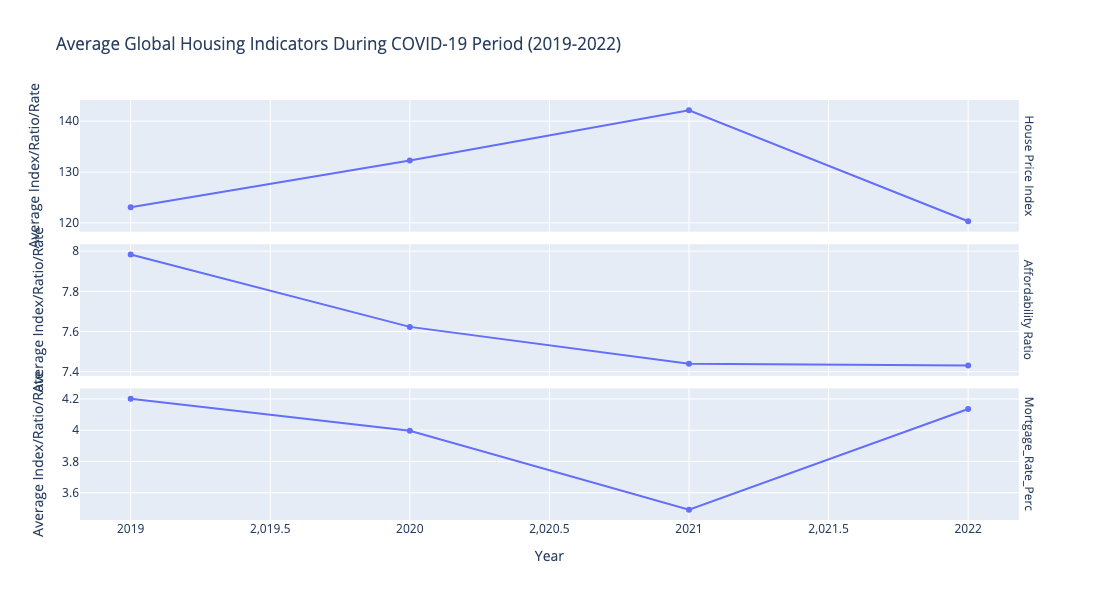

In [255]:
# Visualization: Trend of Key Indicators during COVID-19 ---
# Melt the DataFrame for easier plotting with Plotly Express
avg_indicators_covid_melted = avg_indicators_covid.melt(id_vars='Year', var_name='Indicator', value_name='Average Value')

# Create the faceted line plot
fig_covid_trends = px.line(avg_indicators_covid_melted,
                           x='Year',
                           y='Average Value',
                           facet_row='Indicator', # Separate plot for each indicator
                           title='Average Global Housing Indicators During COVID-19 Period (2019-2022)', #
                           labels={'Average Value': 'Average Index/Ratio/Rate', 'Year': 'Year'}, #
                           markers=True,
                           height=600) # Adjust height as needed


fig_covid_trends.update_yaxes(matches=None, showticklabels=True)
fig_covid_trends.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) 
fig_covid_trends.update_layout(showlegend=False) 
fig_covid_trends.write_html("8.html")
fig_covid_trends.show() 

**Analysis & Findings:**

* **Data Filtered:** The analysis focuses on the average trends across all included countries for the years 2019 through 2022, encompassing the core COVID-19 pandemic period.
* **Visualization:** The line plots above show the trajectory of the global average for the House Price Index (HPI), Affordability Ratio, and Mortgage Rate during these specific years based on the dataset.
* **Observations:**
    * *House Price Index:* The average global HPI increased steadily from 2019 (avg. 123.1) through 2020 (avg. 132.3) and peaked in 2021 (avg. 142.1). However, there was a significant drop in the average HPI in 2022 (avg. 120.3), bringing it below the 2019 level.
    * *Affordability Ratio:* Interestingly, despite the HPI rise initially, the average global Affordability Ratio showed an *improvement* (decreased) consistently from 2019 (avg. 7.98) to 2021 (avg. 7.44) and remained relatively stable at this improved level in 2022 (avg. 7.43). This suggests factors like income changes or falling mortgage rates might have offset the rising house prices on average during 2019-2021.
    * *Mortgage Rate:* The average Mortgage Rate decreased from 2019 (avg. 4.20%) to its lowest point in 2021 (avg. 3.49%). This period of lower rates coincided with the HPI increase. In 2022, the average mortgage rate saw a sharp increase back up to 4.14%, coinciding with the drop observed in the average HPI for that year.
* **Overall Insight:** The COVID-19 period (2019-2022) saw distinct phases in the *average* global housing indicators for the countries studied. Initially (2019-2021), falling average mortgage rates potentially fueled a rise in average house prices, yet average affordability improved. The sharp rise in average mortgage rates in 2022 corresponded with a decline in the average HPI, while average affordability plateaued at the improved level seen in 2021. This highlights the significant interplay between interest rates, house prices, and overall affordability during this volatile period.